# 8INF926 — Comparaison des résultats DP vs NOMAD

Ce notebook compare les résultats des 100 cas entre la programmation dynamique (Projet 1) et NOMAD (Projet 2).

Fichiers utilisés :
- `partie2_validation_100_resultats_python.csv`
- `partie2_validation_100_resultats_nomad.csv`
- `partie2_validation_100_summary_python.csv`
- `partie2_validation_100_summary_nomad.csv`

## Plan d’analyse

1. Charger et fusionner les résultats ligne par ligne
2. Calculer les écarts de puissance et de temps
3. Produire des graphiques de comparaison
4. Formuler des propositions pour le rapport

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
DP_DETAIL = ROOT / 'partie2_validation_100_resultats_python.csv'
NM_DETAIL = ROOT / 'partie2_validation_100_resultats_nomad.csv'
DP_SUMMARY = ROOT / 'partie2_validation_100_summary_python.csv'
NM_SUMMARY = ROOT / 'partie2_validation_100_summary_nomad.csv'

OUT_SCATTER = ROOT / 'images-projet2/partie2_compare_popt_scatter_dp_vs_nomad.png'
OUT_ROWPOWER = ROOT / 'images-projet2/partie2_compare_popt_par_ligne_dp_nomad.png'
OUT_DIFF_HIST = ROOT / 'images-projet2/partie2_compare_diff_mw_hist_dp_nomad.png'
OUT_TIME = ROOT / 'images-projet2/partie2_compare_temps_ms_dp_nomad.png'
OUT_ERRBOX = ROOT / 'images-projet2/partie2_compare_err_pct_box_dp_nomad.png'
OUT_QDIFF = ROOT / 'images-projet2/partie2_compare_debits_mae_par_turbine.png'

for p in [DP_DETAIL, NM_DETAIL, DP_SUMMARY, NM_SUMMARY]:
    if not p.exists():
        raise FileNotFoundError(f'Fichier manquant: {p}')

print('Tous les fichiers requis sont présents.')

Tous les fichiers requis sont présents.


In [2]:
dp = pd.read_csv(DP_DETAIL)
nm = pd.read_csv(NM_DETAIL)

m = nm.merge(dp, on='Row', how='inner', suffixes=('_nomad', '_dp'), validate='one_to_one')

p_nm = m['P_opt_total_nomad'].to_numpy(float)
p_dp = m['P_opt_total'].to_numpy(float)
diff = p_nm - p_dp

t_nm_ms = 1000.0 * m['SolveTime_s_nomad'].to_numpy(float)
t_dp_ms = 1000.0 * m['SolveTime_s'].to_numpy(float)

err_pct_nm = np.abs(m['Err_pct_nomad_minus_real'].to_numpy(float))
err_pct_dp = np.abs(m['Err_pct'].to_numpy(float))

rows = m['Row'].to_numpy(int)

print(f'Nombre de cas fusionnés : {len(m)}')

Nombre de cas fusionnés : 100


In [4]:
summary_compare = pd.DataFrame([
    {
        'Ncases': int(len(m)),
        'MeanDiff_NOMAD_minus_DP_MW': float(np.mean(diff)),
        'MAE_NOMAD_vs_DP_MW': float(np.mean(np.abs(diff))),
        'MaxAbsDiff_NOMAD_vs_DP_MW': float(np.max(np.abs(diff))),
        'RMSE_NOMAD_vs_DP_MW': float(np.sqrt(np.mean(diff**2))),
        'MeanSolveTime_DP_ms': float(np.mean(t_dp_ms)),
        'MeanSolveTime_NOMAD_ms': float(np.mean(t_nm_ms)),
        'SpeedRatio_NOMAD_over_DP': float(np.mean(t_nm_ms) / np.mean(t_dp_ms)),
        'MAPE_DP_pct': float(np.mean(err_pct_dp)),
        'MAPE_NOMAD_pct': float(np.mean(err_pct_nm)),
    }
])

display(summary_compare)

print('Résumé DP:')
display(pd.read_csv(DP_SUMMARY))

print('Résumé NOMAD:')
display(pd.read_csv(NM_SUMMARY))

,Ncases,MeanDiff_NOMAD_minus_DP_MW,MAE_NOMAD_vs_DP_MW,MaxAbsDiff_NOMAD_vs_DP_MW,RMSE_NOMAD_vs_DP_MW,MeanSolveTime_DP_ms,MeanSolveTime_NOMAD_ms,SpeedRatio_NOMAD_over_DP,MAPE_DP_pct,MAPE_NOMAD_pct
0,100,-0.008688,0.008688,0.868816,0.086882,8.057364,13073.150158,1622.509527,23.792451,23.788065


Résumé DP:


,MAE_MW,RMSE_MW,MAPE_pct,NactiveMatchRate_pct,MeanSolveTime_ms,MaxSolveTime_ms,Ncases
0,43.032967,45.109306,23.792451,100.0,8.057364,11.26925,100


Résumé NOMAD:


,MAE_MW_nomad,RMSE_MW_nomad,MAPE_pct_nomad,MeanEval_nomad,MaxEval_nomad,MeanSolveTime_ms_nomad,MaxSolveTime_ms_nomad,SolverMode,Ncases,MeanDiffNomadMinusDP_MW,MAE_NomadVsDP_MW
0,43.024279,45.099675,23.788065,225.77,299,13073.150158,18469.800724,nomad,100,-0.008688,0.008688


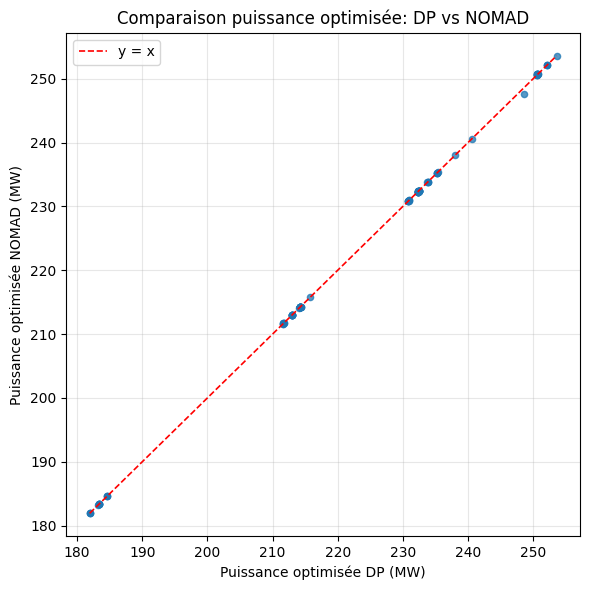

In [5]:
# Graphique 1: nuage puissance NOMAD vs DP
plt.figure(figsize=(6, 6))
plt.scatter(p_dp, p_nm, s=20, alpha=0.75)
pmin, pmax = float(min(p_dp.min(), p_nm.min())), float(max(p_dp.max(), p_nm.max()))
plt.plot([pmin, pmax], [pmin, pmax], 'r--', lw=1.2, label='y = x')
plt.xlabel('Puissance optimisée DP (MW)')
plt.ylabel('Puissance optimisée NOMAD (MW)')
plt.title('Comparaison puissance optimisée: DP vs NOMAD')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_SCATTER, dpi=170)
plt.show()

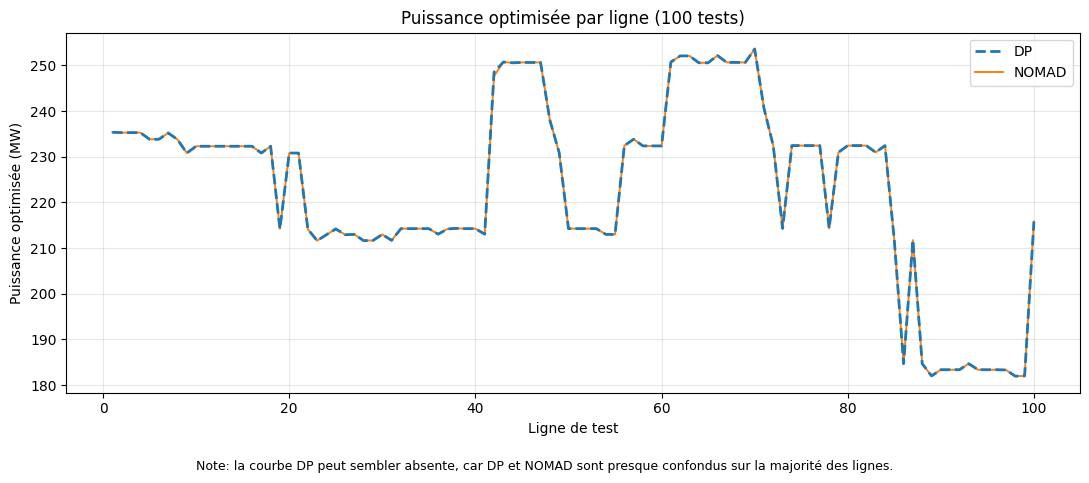

In [18]:
# Graphique 2: puissance optimisée par ligne
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(rows, p_dp, lw=2.0, ls='--', ms=2.5, markevery=5, label='DP', zorder=3)
ax.plot(rows, p_nm, lw=1.4, label='NOMAD')
ax.set_xlabel('Ligne de test')
ax.set_ylabel('Puissance optimisée (MW)')
ax.set_title('Puissance optimisée par ligne (100 tests)')
ax.grid(alpha=0.3)
ax.legend()

# Note explicative sous le graphique
fig.text(
    0.5,
    0.01,
    "Note: la courbe DP peut sembler absente, car DP et NOMAD sont presque confondus sur la majorité des lignes.",
    ha='center',
    fontsize=9,
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(OUT_ROWPOWER, dpi=170)
plt.show()

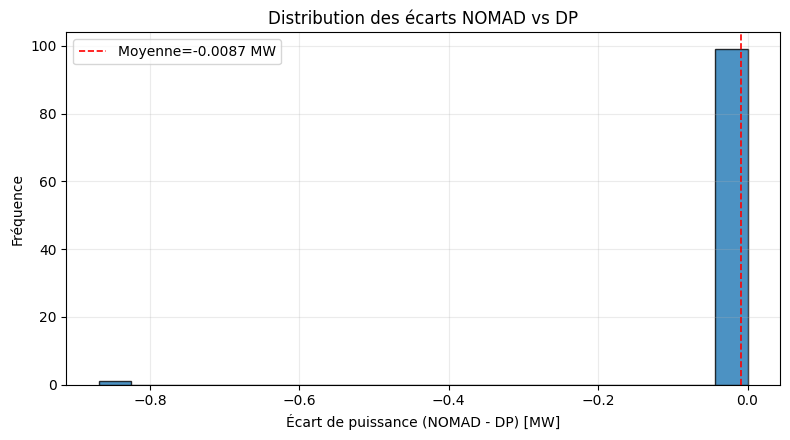

In [7]:
# Graphique 3: histogramme des écarts NOMAD - DP
plt.figure(figsize=(8, 4.5))
plt.hist(diff, bins=20, edgecolor='black', alpha=0.8)
plt.axvline(np.mean(diff), color='red', ls='--', lw=1.2, label=f'Moyenne={np.mean(diff):.4f} MW')
plt.xlabel('Écart de puissance (NOMAD - DP) [MW]')
plt.ylabel('Fréquence')
plt.title('Distribution des écarts NOMAD vs DP')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIFF_HIST, dpi=170)
plt.show()

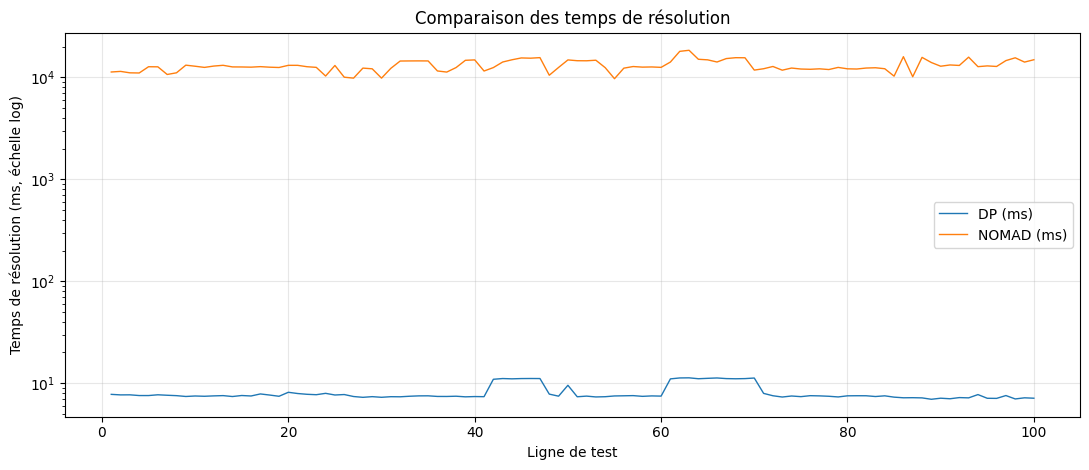

In [8]:
# Graphique 4: comparaison des temps (échelle log)
plt.figure(figsize=(11, 4.8))
plt.plot(rows, t_dp_ms, lw=1.0, label='DP (ms)')
plt.plot(rows, t_nm_ms, lw=1.0, label='NOMAD (ms)')
plt.yscale('log')
plt.xlabel('Ligne de test')
plt.ylabel('Temps de résolution (ms, échelle log)')
plt.title('Comparaison des temps de résolution')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_TIME, dpi=170)
plt.show()

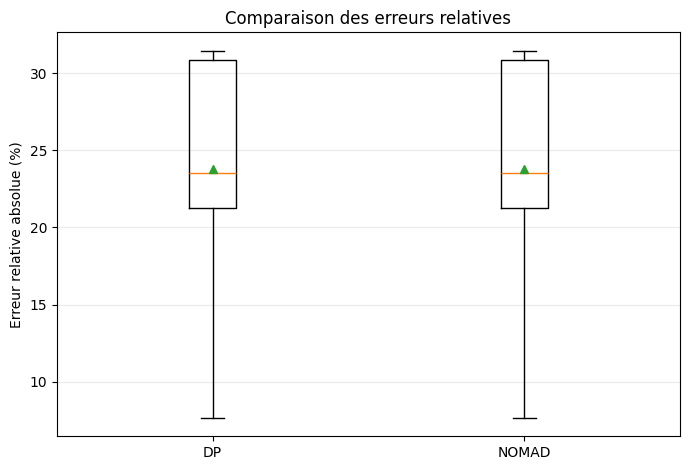

In [9]:
# Graphique 5: boîte à moustaches des erreurs relatives
plt.figure(figsize=(7, 4.8))
plt.boxplot([err_pct_dp, err_pct_nm], tick_labels=['DP', 'NOMAD'], showmeans=True)
plt.ylabel('Erreur relative absolue (%)')
plt.title('Comparaison des erreurs relatives')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_ERRBOX, dpi=170)
plt.show()

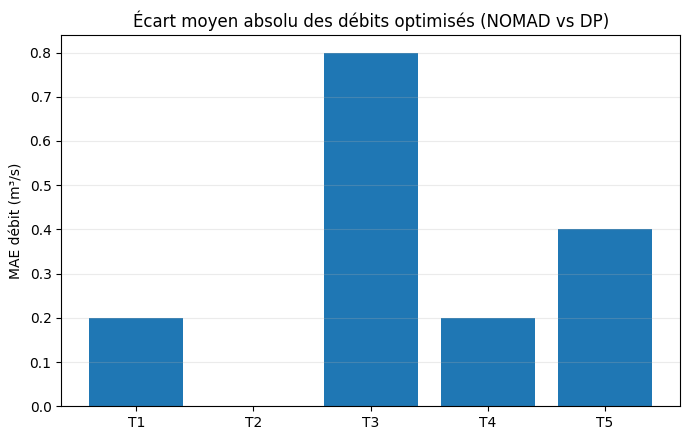

,MAE_Q1_m3s,MAE_Q2_m3s,MAE_Q3_m3s,MAE_Q4_m3s,MAE_Q5_m3s
0,0.2,0.0,0.8,0.2,0.4


In [11]:
# Graphique 6: écart de débit moyen absolu par turbine
q_mae = []
labels = []
for i in range(1, 6):
    qn = m[f'Q{i}_opt_nomad'].to_numpy(float)
    qd = m[f'Q{i}_opt'].to_numpy(float)
    q_mae.append(float(np.mean(np.abs(qn - qd))))
    labels.append(f'T{i}')

plt.figure(figsize=(7, 4.5))
plt.bar(labels, q_mae)
plt.ylabel('MAE débit (m³/s)')
plt.title('Écart moyen absolu des débits optimisés (NOMAD vs DP)')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_QDIFF, dpi=170)
plt.show()

pd.DataFrame([{
    'MAE_Q1_m3s': q_mae[0],
    'MAE_Q2_m3s': q_mae[1],
    'MAE_Q3_m3s': q_mae[2],
    'MAE_Q4_m3s': q_mae[3],
    'MAE_Q5_m3s': q_mae[4],
}])

## Analyse et propositions

### Constats principaux
- Les puissances optimisées DP et NOMAD sont presque identiques (écart moyen très proche de 0 MW).
- Les erreurs par rapport aux données réelles sont quasi équivalentes pour les deux approches.
- Le coût de calcul est très différent : NOMAD est beaucoup plus lent que DP sur ce problème discret.

### Propositions de discussion dans le rapport
1. **Performance** : présenter DP comme référence opérationnelle rapide pour exploitation en temps réel.
2. **Robustesse** : présenter NOMAD comme méthode boîte noire flexible lorsque la structure du modèle évolue.
3. **Compromis** : mentionner qu’une stratégie hybride est possible : DP en production, NOMAD en validation/recalage hors ligne.
4. **Améliorations NOMAD** : tester des `X0` plus proches du réel, réduire l’espace de recherche par restrictions opérationnelles, et ajuster `MAX_EVAL` pour réduire le temps.

### Graphiques recommandés pour le rapport final
- Nuage DP vs NOMAD (puissance optimisée)
- Histogramme de l’écart NOMAD-DP
- Courbe des temps de résolution (échelle log)
- Boîte à moustaches des erreurs relatives
- MAE des débits par turbine

In [12]:
print('Graphiques sauvegardés:')
for p in [OUT_SCATTER, OUT_ROWPOWER, OUT_DIFF_HIST, OUT_TIME, OUT_ERRBOX, OUT_QDIFF]:
    print(' -', p)


Graphiques sauvegardés:
 - /home/johanu/Downloads/cours_uqac/8INF926 - Atelier en optimisation avancée - Hiver 2026 - 01/projet2/partie2_compare_popt_scatter_dp_vs_nomad.png
 - /home/johanu/Downloads/cours_uqac/8INF926 - Atelier en optimisation avancée - Hiver 2026 - 01/projet2/partie2_compare_popt_par_ligne_dp_nomad.png
 - /home/johanu/Downloads/cours_uqac/8INF926 - Atelier en optimisation avancée - Hiver 2026 - 01/projet2/partie2_compare_diff_mw_hist_dp_nomad.png
 - /home/johanu/Downloads/cours_uqac/8INF926 - Atelier en optimisation avancée - Hiver 2026 - 01/projet2/partie2_compare_temps_ms_dp_nomad.png
 - /home/johanu/Downloads/cours_uqac/8INF926 - Atelier en optimisation avancée - Hiver 2026 - 01/projet2/partie2_compare_err_pct_box_dp_nomad.png
 - /home/johanu/Downloads/cours_uqac/8INF926 - Atelier en optimisation avancée - Hiver 2026 - 01/projet2/partie2_compare_debits_mae_par_turbine.png
